In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

In [4]:
file = np.genfromtxt('/Users/eleonora/Desktop/mistral/LUT/TZ_data.dat', comments='#')
genn = pd.DataFrame(file, columns=['EL', 'TY', 'TZ', 'err_TZ', 'D_az', 'D_el'])
#Elevation
#TZ
#best TZ
#errore
#DEl armin (alla pos di best focus)
#DAz arcsec
#salita/discesa

table_csv = '/Users/eleonora/Desktop/mistral/OBS/SRT-marzo/MATRICI/Tabella_MATRICI.csv'
tab = pd.read_csv(table_csv)

feb = tab[tab['Data']=='febbraio'][0:-1]

mar = tab[tab['Data']!='febbraio'][0:29]

tab

,Data,SORGENTE,AZ,range EL,EL,TZ,err_TZ,TY,err_TY,TZ lin mapping,TY lin mapping
0,febbraio,marte,NaN,35-40,37.0,1.0,1.0,0.0,1.0,1.0,-1.0
1,febbraio,marte,NaN,35-40,37.0,1.0,1.0,0.0,1.0,1.0,-2.0
2,febbraio,marte,NaN,40-50,45.0,1.0,1.0,-2.0,1.0,1.0,-1.0
3,febbraio,marte,NaN,40-50,45.0,1.0,1.0,-2.0,1.0,1.0,-2.0
4,febbraio,marte,NaN,50-60,55.0,0.0,1.0,-3.0,1.0,0.0,-2.5
5,febbraio,marte,NaN,50-60,55.0,0.0,1.0,-3.0,1.0,0.0,-5.0
6,febbraio,marte,NaN,60-70,65.0,-1.0,1.0,0.0,1.0,-1.0,-2.0
7,febbraio,marte,NaN,60-70,65.0,-1.0,1.0,0.0,1.0,-2.0,0.0
8,febbraio,marte,NaN,70-80,73.0,NaN,1.0,-2.5,1.0,NaN,-2.0
9,20250330-212707,marte,NaN,NaN,47.0,1.0,1.0,-4.0,1.0,1.0,-3.7


In [5]:
def add_checkpoints(tabel, tabtz, taberr):
    el = [0, 15]
    el+= [tabel]
    el += [80, 90]
    el = np.hstack(el)

    TZ = [-175, -57]
    TZ += [tabtz]
    TZ += [5, 35]
    TZ = np.hstack(TZ)

    err = [1, 1]
    err += [taberr]
    err += [1]
    err = np.hstack(err)
    return el, TZ, err

           3          2
-0.001318 x + 0.2125 x - 11.17 x + 185
pol mistral feb
          6             5             4           3          2
9.58e-09 x - 2.586e-06 x + 0.0002607 x - 0.01211 x + 0.2562 x - 2.282 x + 10
pol mistral mar
           6            5             4           3          2
9.956e-09 x - 2.68e-06 x + 0.0002682 x - 0.01226 x + 0.2522 x - 2.187 x + 9.969


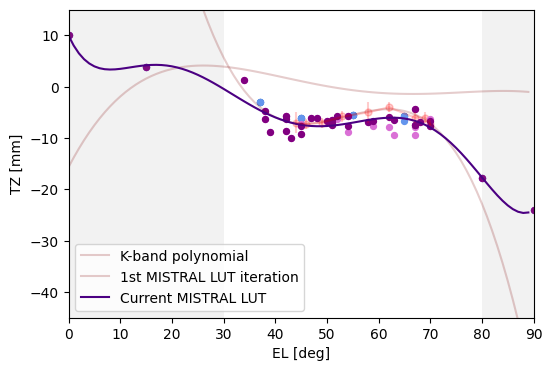

In [10]:
genn_el, genn_TZ, genn_err = genn['EL'].values, genn['TZ'].values, genn['err_TZ'].values

fit_genn = np.polyfit(genn_el, genn_TZ, deg=3)
pol_orig_MISTRAL_genn = np.poly1d(fit_genn)
print(pol_orig_MISTRAL_genn)

range_el = range(0,90,1)
coeff_K=np.array(list(reversed([-15.6669651675,1.9293068324,-0.0628990613,0.0007771141,-0.0000032940])))
pol_K = np.poly1d(coeff_K)


feb_mat_el = feb['EL']
feb_mat_TZ = feb['TZ']
feb_mat_TZ_linmap = feb['TZ lin mapping']
feb_mat_err = feb['err_TZ']
feb_mat_el, feb_mat_TZ, feb_mat_err = add_checkpoints(feb['EL'].values, feb['TZ'].values, feb['err_TZ'].values)
feb_mat_el, feb_mat_TZ_linmap, feb_mat_err = add_checkpoints(feb['EL'].values, feb['TZ lin mapping'].values, feb['err_TZ'].values)
feb_mat_TZ = np.array(pol_orig_MISTRAL_genn(feb_mat_el)) + np.array(feb_mat_TZ)
feb_mat_TZ_linmap = np.array(pol_orig_MISTRAL_genn(feb_mat_el)) + np.array(feb_mat_TZ_linmap)
fit_matrix_feb = np.polyfit(feb_mat_el, np.mean([feb_mat_TZ, feb_mat_TZ_linmap], axis=0), deg=6)
pol_MISTRAL_matrix_feb = np.poly1d(fit_matrix_feb)
print('pol mistral feb')
print(pol_MISTRAL_matrix_feb)

mar_mat_el = mar['EL']
mar_mat_TZ = mar['TZ']
mar_mat_TZ_linmap = mar['TZ lin mapping']
mar_mat_err = mar['err_TZ']
mar_mat_el, mar_mat_TZ, mar_mat_err = add_checkpoints(mar['EL'].values, mar['TZ'].values, mar['err_TZ'].values)
mar_mat_el, mar_mat_TZ_linmap, mar_mat_err = add_checkpoints(mar['EL'].values, mar['TZ lin mapping'].values, mar['err_TZ'].values)
mar_mat_TZ = np.array(pol_orig_MISTRAL_genn(mar_mat_el)) + np.array(mar_mat_TZ)
mar_mat_TZ_linmap = np.array(pol_orig_MISTRAL_genn(mar_mat_el)) + np.array(mar_mat_TZ_linmap)

fit_matrix_mar = np.polyfit(mar_mat_el, np.mean([mar_mat_TZ, mar_mat_TZ_linmap], axis=0), deg=6)
pol_MISTRAL_matrix_mar = np.poly1d(fit_matrix_mar)
print('pol mistral mar')
print(pol_MISTRAL_matrix_mar)

range_el = range(0,90,1)
mpl.rcParams['lines.markersize'] = 5
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
ax.plot(range_el, pol_K(range_el), label='K-band polynomial', c='maroon', alpha=0.2)
ax.scatter(genn_el, genn_TZ, c='red', alpha=0.2)
ax.errorbar(genn_el, genn_TZ, genn_err, c='red', alpha=0.2)
ax.plot(range_el, pol_orig_MISTRAL_genn(range_el), label='1st MISTRAL LUT iteration', c='maroon', alpha=0.2)
ax.scatter(feb_mat_el, feb_mat_TZ, color='steelblue', s=18) #label='matrix occhio'
ax.scatter(feb_mat_el, feb_mat_TZ_linmap, color='cornflowerblue', s=18) # label='matrix lin mapping'
#ax.plot(range_el, pol_MISTRAL_matrix_feb(range_el), label='Feb MISTRAL pol', c='cadetblue')
ax.scatter(mar_mat_el, mar_mat_TZ, color='orchid', s=18) #label='matrix occhio marzo'
ax.scatter(mar_mat_el, mar_mat_TZ_linmap, color='purple', s=18) # label='matrix lin mapping marzo'
ax.plot(range_el, pol_MISTRAL_matrix_mar(range_el), label='Current MISTRAL LUT', c='indigo')
ymin = -45
ymax = 15
xmin = 0
xmax = 90
ax.axhspan(ymin, ymax, 0 , 30/xmax, facecolor='grey', alpha=0.1)
ax.axhspan(ymin, ymax, 80/xmax , 90/xmax, facecolor='grey', alpha=0.1)
ax.set_xlabel('EL [deg]')
ax.set_ylabel('TZ [mm]')
ax.set_ylim(ymin, ymax)
ax.set_xlim(0,90)
#for i, label in enumerate(dict['TZ']):
#    ax.annotate('TZ'+str(label), (dict['EL'][i], dict['TZ_choosen'][i]),  xytext=(5, -5), #, xytext=(20, -20),
#        textcoords='offset points')#, arrowprops=dict(arrowstyle='->'))
plt.legend(loc='lower left')
plt.show()

In [ ]:
dict = {
    'EL' : [44, 49, 53, 58, 62, 67, 70],
    'TY' : [-2.5, -2.5, -5, -5, -2.5, -5, 0],
    'TZ_choosen' : [-7, -7, -6, -5, -4, -6, -7],
    'bestA' : [-7, -7.00, -5.80, -4.90, -3.10, -6.00, -7.10],
    'bestFWHM' : [-7, -6.90, -5.80, -4.70, -4.10, -5.80, -7.50],
    'AZoffset' : [np.nan, -45.040, -1.963, np.nan, 1.978, -4.847, 3.517],
    'ELoffset' : [np.nan, 12.175, -22.443, np.nan, 6.909, 6.887, 28.316],
}

dict

{'EL': [44, 49, 53, 58, 62, 67, 70],
 'TY': [-2.5, -2.5, -5, -5, -2.5, -5, 0],
 'TZ_choosen': [-7, -7, -6, -5, -4, -6, -7],
 'bestA': [-7, -7.0, -5.8, -4.9, -3.1, -6.0, -7.1],
 'bestFWHM': [-7, -6.9, -5.8, -4.7, -4.1, -5.8, -7.5],
 'AZoffset': [nan, -45.04, -1.963, nan, 1.978, -4.847, 3.517],
 'ELoffset': [nan, 12.175, -22.443, nan, 6.909, 6.887, 28.316]}

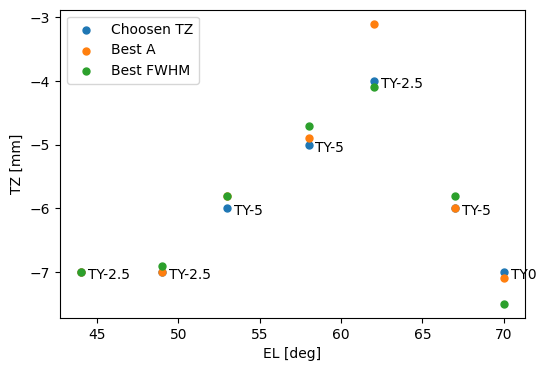

In [ ]:
mpl.rcParams['lines.markersize'] = 5
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
ax.scatter(dict['EL'], dict['TZ_choosen'], label='Choosen TZ')
ax.scatter(dict['EL'], dict['bestA'], label='Best A')
ax.scatter(dict['EL'], dict['bestFWHM'], label='Best FWHM')
ax.set_xlabel('EL [deg]')
ax.set_ylabel('TZ [mm]')
for i, label in enumerate(dict['TY']):
    ax.annotate('TY'+str(label), (dict['EL'][i], dict['TZ_choosen'][i]),  xytext=(5, -5), #, xytext=(20, -20),
        textcoords='offset points')#, arrowprops=dict(arrowstyle='->'))
plt.legend(loc='upper left')
plt.show()

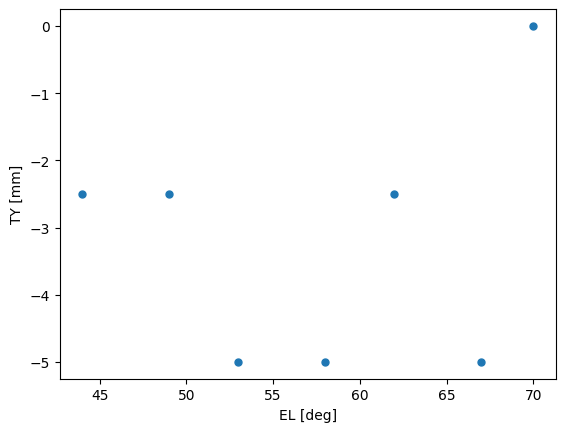

In [ ]:
plt.scatter(dict['EL'], dict['TY'])
plt.xlabel('EL [deg]')
plt.ylabel('TY [mm]')
plt.show()


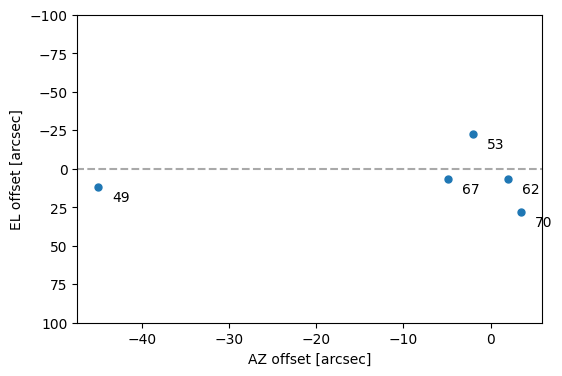

In [ ]:
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
ax.scatter(dict['AZoffset'], dict['ELoffset'])
ax.set_xlabel('AZ offset [arcsec]')
ax.set_ylabel('EL offset [arcsec]')
ax.axhline(0, np.nanmin(dict['AZoffset'])-5, np.nanmax(dict['AZoffset'])+5, color='darkgrey', linestyle='--')
ax.set_ylim(100, -100)
for i, label in enumerate(dict['EL']):
    ax.annotate(label, (dict['AZoffset'][i], dict['ELoffset'][i]),  xytext=(10, -10), #, xytext=(20, -20),
        textcoords='offset points')#, arrowprops=dict(arrowstyle='->'))
plt.show()

In [ ]:
np.mean([matrix_data_occhio, matrix_data_linmapping], axis=0)

array([ 10.00516428,   3.88134276,  -3.94300473,  -6.18263111,
        -5.46883152,  -6.22957419, -12.65217524, -24.02333925])